# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset


## Setup

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [3]:
print("Số dòng:", df.shape[0], "| Số cột:", df.shape[1])
print()
df.info()

Số dòng: 1338 | Số cột: 7

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## A.2. Missing values & Duplicate data

In [4]:
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing>0] if missing.sum()>0 else "Không có cột nào thiếu dữ liệu.")
print()
print("Duplicate rows (toàn bộ):", df.duplicated().sum())

Missing values:
Không có cột nào thiếu dữ liệu.

Duplicate rows (toàn bộ): 1


## A.3. Invalid values

In [5]:
print("age <= 0:", (df['age']<=0).sum())
print("children < 0:", (df['children']<0).sum())
print()
print("=> Dữ liệu khá sạch: không missing, không duplicate, không giá trị vô lý.")

age <= 0: 0
children < 0: 0

=> Dữ liệu khá sạch: không missing, không duplicate, không giá trị vô lý.


## A.4. Create a new column
Tạo cột `bmi_group`: Underweight (<18.5), Normal (18.5-25), Overweight (25-30), Obese (>=30).

In [6]:
df['bmi_group'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, np.inf], labels=['Underweight', 'Normal weight', 'Overweight', 'Obese'])
df.head(5)

,age,sex,bmi,children,smoker,region,charges,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal weight
4,32,male,28.880,0,no,northwest,3866.85520,Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS

## Group 1 — Central Tendency (mean, median, mode)

In [7]:
for col in ['age', 'bmi', 'charges']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")
print()
print("Mode smoker:", df['smoker'].mode()[0])
print("Mode region:", df['region'].mode()[0])

age: Mean=39.21, Median=39.00, Mode=18.00
bmi: Mean=30.66, Median=30.40, Mode=32.30
charges: Mean=13270.42, Median=9382.03, Mode=1639.56

Mode smoker: no
Mode region: southeast


## Group 2 — Dispersion (range, var, std, IQR, CV)

In [8]:
for col in ['age', 'bmi', 'charges']:
    s = df[col]
    range_ = s.max() - s.min()
    std_ = s.std()
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    cv = std_ / s.mean()
    print(f"--- {col} ---")
    print(f"Range={range_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

--- age ---
Range=46.00, Std=14.05, IQR=24.00, CV=0.36
--- bmi ---
Range=37.17, Std=6.10, IQR=8.40, CV=0.20
--- charges ---
Range=62648.55, Std=12110.01, IQR=11899.63, CV=0.91


## Group 3 — Location and Shape (Percentile, Skewness, Kurtosis)

--- age ---
P25=27.00, P50=39.00, P75=51.00
Skewness=0.06, Kurtosis=-1.24
--- bmi ---
P25=26.30, P50=30.40, P75=34.69
Skewness=0.28, Kurtosis=-0.06
--- charges ---
P25=4740.29, P50=9382.03, P75=16639.91
Skewness=1.51, Kurtosis=1.60


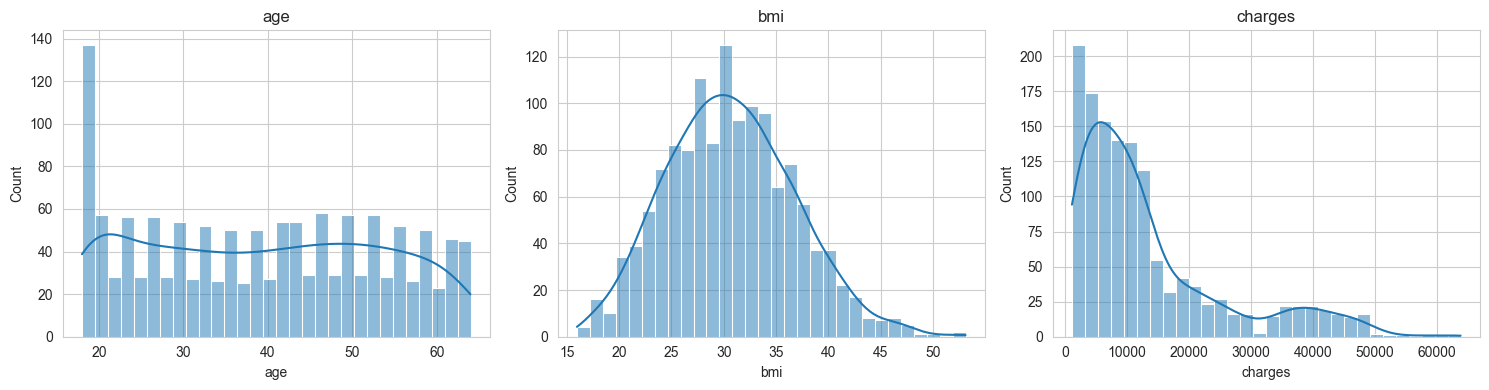

Nhận xét: charges lệch phải rất mạnh (Skewness=1.51, Kurtosis=1.60) và CV cao (0.91), cho thấy chi phí bảo hiểm có sự phân hóa lớn giữa các nhóm khách hàng (đặc biệt là nhóm hút thuốc).


In [9]:
for col in ['age', 'bmi', 'charges']:
    s = df[col]
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0]); axes[0].set_title('age')
sns.histplot(df['bmi'], bins=30, kde=True, ax=axes[1]); axes[1].set_title('bmi')
sns.histplot(df['charges'], bins=30, kde=True, ax=axes[2]); axes[2].set_title('charges')
plt.tight_layout(); plt.show()

print("Nhận xét: charges lệch phải rất mạnh (Skewness=1.51, Kurtosis=1.60) và CV cao (0.91), cho thấy chi phí bảo hiểm có sự phân hóa lớn giữa các nhóm khách hàng (đặc biệt là nhóm hút thuốc).")

---
# PHẦN C — DEFINE THE QUESTION

Mỗi câu hỏi dưới đây theo đúng cấu trúc: **Câu hỏi → Code → Kết quả → Insight**.

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

Chi phí bảo hiểm trung bình theo tình trạng hút thuốc (USD):
smoker
no      8434.27
yes    32050.23
Name: charges, dtype: float64

=> Người hút thuốc trả chi phí gấp 3.80 lần người không hút thuốc (32,050.23 USD vs 8,434.27 USD).

Chi phí theo Vùng và Tình trạng hút thuốc:
 smoker          no       yes  ratio
region                             
northeast  9165.53  29673.54   3.24
northwest  8556.46  30192.00   3.53
southeast  8032.22  34845.00   4.34
southwest  8019.28  32269.06   4.02


C:\Users\Cai Nhi\AppData\Local\Temp\ipykernel_9800\1884792115.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='smoker', y='charges', ax=axes[0], palette='Set2')


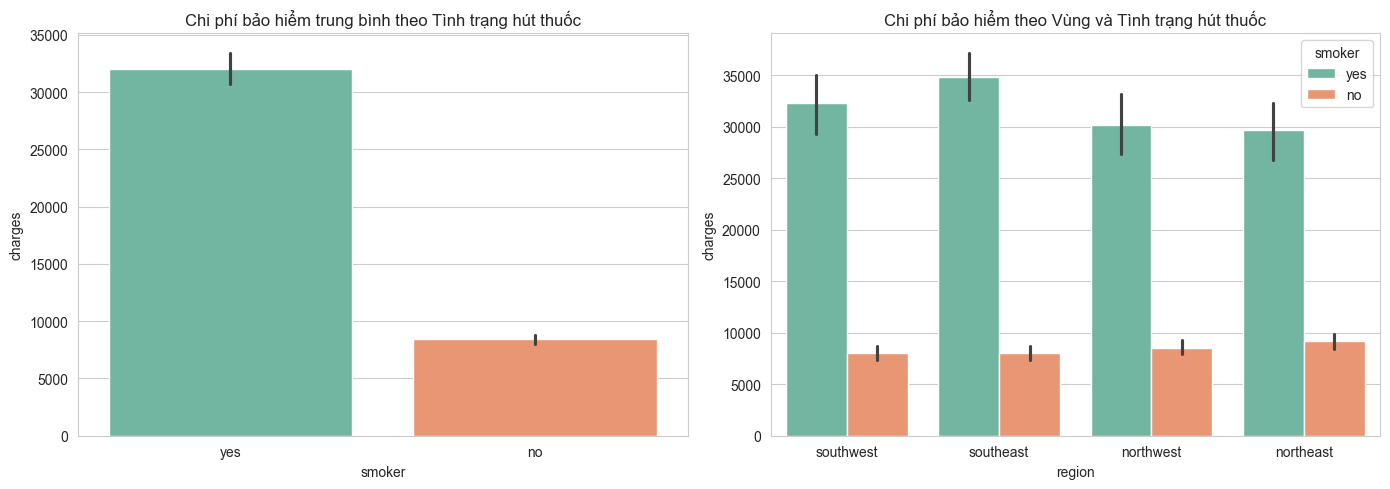

In [10]:
smoker_charge = df.groupby('smoker')['charges'].mean()
ratio = smoker_charge['yes'] / smoker_charge['no']

print("Chi phí bảo hiểm trung bình theo tình trạng hút thuốc (USD):")
print(smoker_charge.round(2))
print(f"\n=> Người hút thuốc trả chi phí gấp {ratio:.2f} lần người không hút thuốc (32,050.23 USD vs 8,434.27 USD).")

reg_smoker = df.groupby(['region', 'smoker'])['charges'].mean().unstack()
reg_smoker['ratio'] = reg_smoker['yes'] / reg_smoker['no']
print("\nChi phí theo Vùng và Tình trạng hút thuốc:\n", reg_smoker.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='smoker', y='charges', ax=axes[0], palette='Set2')
axes[0].set_title('Chi phí bảo hiểm trung bình theo Tình trạng hút thuốc')

sns.barplot(data=df, x='region', y='charges', hue='smoker', ax=axes[1], palette='Set2')
axes[1].set_title('Chi phí bảo hiểm theo Vùng và Tình trạng hút thuốc')
plt.tight_layout(); plt.show()

**Insight:** Người hút thuốc chịu chi phí bảo hiểm trung bình cao gấp **3.80 lần** so với người không hút thuốc ($32,050 vs $8,434). Mức chênh lệch này duy trì ở mức cao trên toàn bộ các vùng, trong đó vùng **southeast** có mức chênh lệch lớn nhất (gấp 4.34 lần). Điều này khẳng định thói quen hút thuốc là yếu tố rủi ro hàng đầu đẩy chi phí bảo hiểm lên cao vượt trội.

## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

Tương quan BMI - Charges nhóm Hút thuốc: Pearson=0.806, Spearman=0.834
Tương quan BMI - Charges nhóm Không hút thuốc: Pearson=0.084, Spearman=0.105


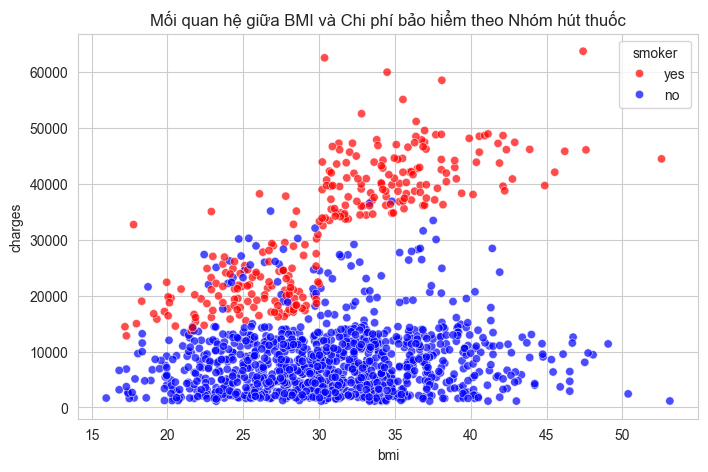

In [11]:
corr_smoker = df[df['smoker'] == 'yes']['bmi'].corr(df[df['smoker'] == 'yes']['charges'])
corr_non_smoker = df[df['smoker'] == 'no']['bmi'].corr(df[df['smoker'] == 'no']['charges'])

sp_smoker = df[df['smoker'] == 'yes']['bmi'].corr(df[df['smoker'] == 'yes']['charges'], method='spearman')
sp_non_smoker = df[df['smoker'] == 'no']['bmi'].corr(df[df['smoker'] == 'no']['charges'], method='spearman')

print(f"Tương quan BMI - Charges nhóm Hút thuốc: Pearson={corr_smoker:.3f}, Spearman={sp_smoker:.3f}")
print(f"Tương quan BMI - Charges nhóm Không hút thuốc: Pearson={corr_non_smoker:.3f}, Spearman={sp_non_smoker:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.7, ax=ax, palette={'yes': 'red', 'no': 'blue'})
ax.set_title('Mối quan hệ giữa BMI và Chi phí bảo hiểm theo Nhóm hút thuốc')
plt.show()

**Insight:** BMI tương quan **rất mạnh** với chi phí bảo hiểm ở nhóm người hút thuốc (Pearson r = **0.806**), trong khi ở nhóm không hút thuốc, mối tương quan này **rất yếu** (Pearson r = **0.084**). Tác động tiêu cực của BMI (béo phì) lên chi phí bảo hiểm bị bộc phát mạnh mẽ khi kết hợp với yếu tố hút thuốc.

## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

Chi phí bảo hiểm trung bình theo Vùng (USD):
 region
southeast    14735.41
northeast    13406.38
northwest    12417.58
southwest    12346.94
Name: charges, dtype: float64

=> Vùng có chi phí cao nhất: southeast ($14735.41)
=> Chênh lệch so với vùng thấp nhất (southwest): $2388.47


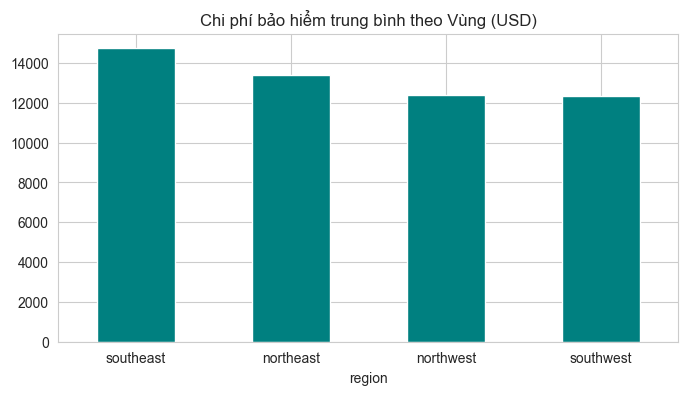

In [12]:
reg_charge = df.groupby('region')['charges'].mean().sort_values(ascending=False)
print("Chi phí bảo hiểm trung bình theo Vùng (USD):\n", reg_charge.round(2))

top_region = reg_charge.index[0]
low_region = reg_charge.index[-1]
diff_reg = reg_charge.iloc[0] - reg_charge.iloc[-1]

print(f"\n=> Vùng có chi phí cao nhất: {top_region} (${reg_charge.iloc[0]:.2f})")
print(f"=> Chênh lệch so với vùng thấp nhất ({low_region}): ${diff_reg:.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
reg_charge.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Chi phí bảo hiểm trung bình theo Vùng (USD)')
plt.xticks(rotation=0); plt.show()

**Insight:** Vùng **southeast** có chi phí bảo hiểm trung bình cao nhất ($14,735.41), cao hơn vùng thấp nhất (southwest: $12,346.94) khoảng $2,388.47. Nguyên nhân chính là vùng southeast tập trung tỷ lệ người có BMI cao (béo phì) và người hút thuốc cao hơn so với các vùng khác.

## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

Chi phí bảo hiểm trung bình theo số con (USD):
 children
0    12365.98
1    12731.17
2    15073.56
3    15355.32
4    13850.66
5     8786.04
Name: charges, dtype: float64


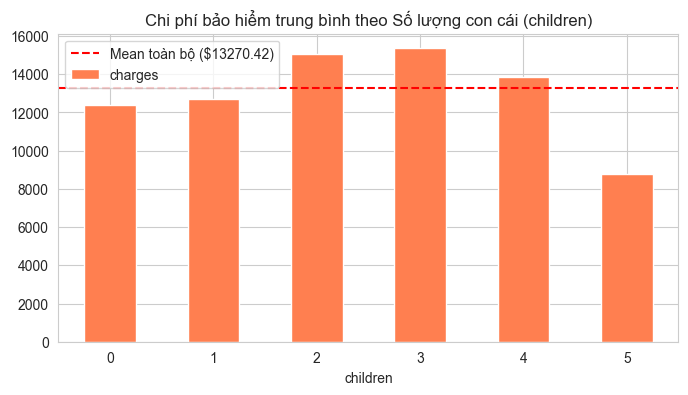

In [13]:
child_charge = df.groupby('children')['charges'].mean()
print("Chi phí bảo hiểm trung bình theo số con (USD):\n", child_charge.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
child_charge.plot(kind='bar', ax=ax, color='coral')
ax.axhline(df['charges'].mean(), color='red', linestyle='--', label=f'Mean toàn bộ (${df["charges"].mean():.2f})')
ax.set_title('Chi phí bảo hiểm trung bình theo Số lượng con cái (children)')
plt.xticks(rotation=0); plt.legend(); plt.show()

**Insight:** Chi phí bảo hiểm trung bình tăng nhẹ từ nhóm 0 con ($12,365.98) đến đỉnh điểm ở nhóm 2-3 con ($15,073 - $15,355), sau đó giảm ở nhóm 4-5 con. Số lượng con cái không phải là yếu tố tác động tuyến tính đơn thuần lên chi phí bảo hiểm mà bị chi phối bởi độ tuổi người phụ thuộc và các gói bảo hiểm gia đình.

## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

Pearson correlation (age vs charges): 0.299
Spearman correlation (age vs charges): 0.534


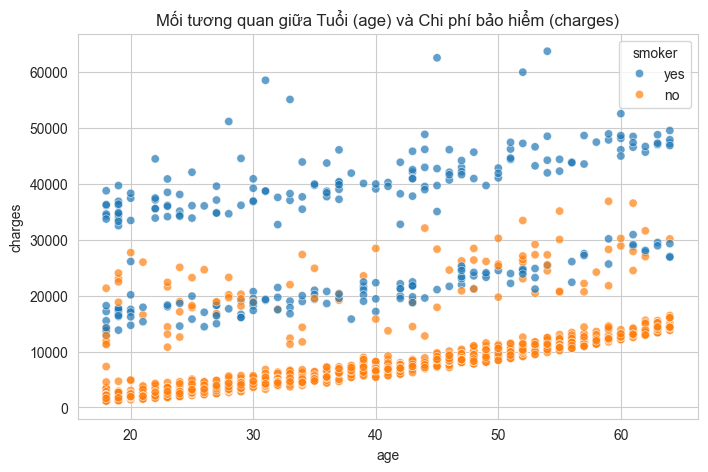

In [14]:
corr_age_pearson = df['age'].corr(df['charges'])
corr_age_spearman = df['age'].corr(df['charges'], method='spearman')

print(f"Pearson correlation (age vs charges): {corr_age_pearson:.3f}")
print(f"Spearman correlation (age vs charges): {corr_age_spearman:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7, ax=ax)
ax.set_title('Mối tương quan giữa Tuổi (age) và Chi phí bảo hiểm (charges)')
plt.show()

**Insight:** Tuổi tác có mối tương quan **dương rõ rệt** với chi phí bảo hiểm (Spearman r = **0.534**, Pearson r = **0.299**). Chi phí bảo hiểm tăng dần theo độ tuổi ở tất cả các tầng nhóm, thể hiện xu hướng rủi ro sức khỏe tăng tiến theo thời gian.

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Medical Insurance Cost.

**Insight:** Thói quen **Hút thuốc (Smoker)** và **Chỉ số khối cơ thể (BMI)** là hai yếu tố tác động mạnh nhất và có tính tương tác trực tiếp tới chi phí bảo hiểm y tế. Người hút thuốc phải trả chi phí gấp 3.8 lần người không hút thuốc, và yếu tố BMI chỉ gây bùng nổ chi phí khi kết hợp với thói quen hút thuốc (r = 0.806). Tuổi tác tác động tăng tiến đồng đều theo thời gian, trong khi yếu tố Vùng miền thể hiện sự phân hóa chi phí do tỷ lệ béo phì và hút thuốc khác nhau giữa các vùng.

---
# TỔNG KẾT

| Phần | Trả lời câu hỏi |
|---|---|
| A — Data Profiling | Dữ liệu có sạch, đáng tin cậy để phân tích không? |
| B — Descriptive Statistics | Từng biến (age, bmi, charges) có đặc điểm gì (trung tâm, phân tán, hình dạng)? |
| C — Define the Question | Trả lời được bao nhiêu câu hỏi kinh doanh thật, có insight + khuyến nghị hành động? |

— khác với việc chỉ chạy `describe()` hay `value_counts()` đơn thuần, mỗi phân tích ở Phần C đều xuất phát từ 1 câu hỏi cụ thể và kết thúc bằng 1 insight có thể hành động được, đúng tinh thần "data storytelling" mà nhà tuyển dụng Data Analyst luôn tìm kiếm.